## SVD — Matrix Factorization
**Dataset:** CiaoDVD

---
## 1. Imports & Setup

In [ ]:
!pip install scikit-surprise
!pip install "numpy<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 60.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 r

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split, GridSearchCV

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Load & Preprocess CiaoDVD Data

The CiaoDVD `movie-ratings.txt` file contains:  
`user_id | movie_id | category_id | review_id | rating | date`  
We keep only `user_id`, `movie_id`, and `rating`.

In [2]:
import os
import urllib.request
import zipfile

# ── Locate the ratings file (handles both local and Colab/repo layouts) ────────
CANDIDATE_PATHS = [
    '../data/movie-ratings.txt',
    '../data/CiaoDVD/movie-ratings.txt',
    'data/movie-ratings.txt',
    'movie-ratings.txt',
]

DATA_PATH = None
# We'll skip the local check if we just downloaded the zip incorrectly
if not os.path.exists('CiaoDVD.zip') and not os.path.exists('CiaoDVD/movie-ratings.txt'):
    for p in CANDIDATE_PATHS:
        if os.path.exists(p) and not p == 'movie-ratings.txt': # Avoid using the broken zip file
            DATA_PATH = p
            break

if DATA_PATH is None:
    print('Dataset not found or needs extraction. Downloading...')
    DATA_URL = 'https://guoguibing.github.io/librec/datasets/CiaoDVD.zip'
    try:
        # Download the zip file
        urllib.request.urlretrieve(DATA_URL, 'CiaoDVD.zip')
        print('Download complete. Extracting...')

        # Extract the zip file
        with zipfile.ZipFile('CiaoDVD.zip', 'r') as zip_ref:
            zip_ref.extractall('CiaoDVD_extracted')

        # The dataset inside the zip should contain the file
        DATA_PATH = 'CiaoDVD_extracted/movie-ratings.txt'
        print('Extraction complete.')
    except Exception as e:
        raise FileNotFoundError(
            f"Failed to download or extract the dataset. Error: {e}"
        )

print(f'Using dataset: {DATA_PATH}')

Dataset not found or needs extraction. Downloading...
Download complete. Extracting...
Extraction complete.
Using dataset: CiaoDVD_extracted/movie-ratings.txt


In [3]:
# ── Load raw data ──────────────────────────────────────────────────────────────
raw_df = pd.read_csv(
    DATA_PATH,
    sep=',',
    header=None,
    names=['user_id', 'movie_id', 'category_id', 'review_id', 'rating', 'date'],
    engine='python'
)

print(f'Raw shape: {raw_df.shape}')
raw_df.head()

Raw shape: (72665, 6)


,user_id,movie_id,category_id,review_id,rating,date
0,1,1,1,1,5,2000-07-12
1,2,1,1,2,5,2000-07-12
2,3,1,1,3,5,2000-07-12
3,4,1,1,4,4,2000-07-12
4,5,1,1,5,4,2000-07-12


In [4]:
# ── Preprocessing ──────────────────────────────────────────────────────────────
df = raw_df[['user_id', 'movie_id', 'rating']].copy()

# 1) Drop missing values
df.dropna(inplace=True)

# 2) Keep only valid ratings (CiaoDVD uses 1–5 scale)
RATING_MIN, RATING_MAX = 1, 5
df = df[(df['rating'] >= RATING_MIN) & (df['rating'] <= RATING_MAX)]

# 3) Remove duplicate (user, item) pairs — keep the most recent (last) entry
df.drop_duplicates(subset=['user_id', 'movie_id'], keep='last', inplace=True)

# 4) Cold-start filter: keep users with ≥5 ratings & items with ≥5 ratings
user_counts = df['user_id'].value_counts()
item_counts = df['movie_id'].value_counts()
df = df[
    df['user_id'].isin(user_counts[user_counts >= 5].index) &
    df['movie_id'].isin(item_counts[item_counts >= 5].index)
]

df.reset_index(drop=True, inplace=True)

print(f'Cleaned shape : {df.shape}')
print(f'Unique users  : {df["user_id"].nunique():,}')
print(f'Unique movies : {df["movie_id"].nunique():,}')
print(f'Rating range  : [{df["rating"].min()} – {df["rating"].max()}]')
print(f'Avg rating    : {df["rating"].mean():.3f}')

sparsity = 1 - len(df) / (df['user_id'].nunique() * df['movie_id'].nunique())
print(f'Matrix sparsity: {sparsity:.4%}')

Cleaned shape : (33607, 3)
Unique users  : 2,567
Unique movies : 3,063
Rating range  : [1 – 5]
Avg rating    : 4.043
Matrix sparsity: 99.5726%


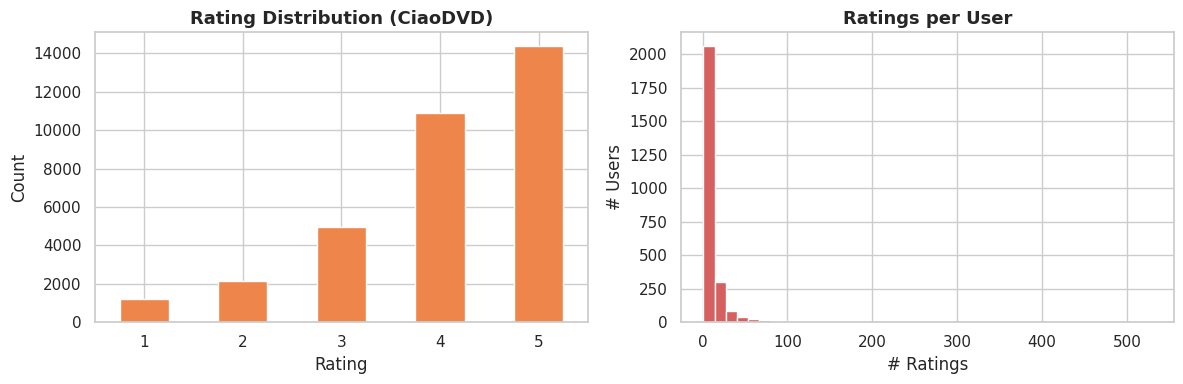

In [5]:
# ── Rating distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=sns.color_palette('muted')[1], edgecolor='white'
)
axes[0].set_title('Rating Distribution (CiaoDVD)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['user_id'].value_counts().pipe(
    lambda s: axes[1].hist(s, bins=40, color=sns.color_palette('muted')[3], edgecolor='white')
)
axes[1].set_title('Ratings per User', fontsize=13, fontweight='bold')
axes[1].set_xlabel('# Ratings')
axes[1].set_ylabel('# Users')

plt.tight_layout()
os.makedirs('./results', exist_ok=True)
plt.savefig('./results/svd_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Build Surprise Dataset & Train/Test Split (80/20)

In [6]:
reader  = Reader(rating_scale=(RATING_MIN, RATING_MAX))
dataset = Dataset.load_from_df(df[['user_id', 'movie_id', 'rating']], reader)

# 80/20 split with fixed random state for reproducibility
trainset, testset = train_test_split(dataset, test_size=0.20, random_state=42)

print(f'Training ratings : {trainset.n_ratings:,}')
print(f'Test ratings     : {len(testset):,}')

Training ratings : 26,885
Test ratings     : 6,722


---
## 4. Hyperparameter Tuning via GridSearchCV (5-Fold CV)

Surprise's **SVD** implements Simon Funk's SVD with user and item biases learned via **SGD**. The key hyperparameters are:

| Parameter | Meaning |
|---|---|
| `n_factors` | Number of latent dimensions (rank of the factorisation) |
| `n_epochs` | Number of SGD iterations over the training set |
| `lr_all` | Learning rate applied to all parameters |
| `reg_all` | L2 regularisation strength applied to all parameters |

In [7]:
param_grid = {
    'n_factors': [50, 100, 150],
    'n_epochs':  [20, 30],
    'lr_all':    [0.002, 0.005],
    'reg_all':   [0.02, 0.1],
}

print('Running GridSearchCV for SVD (this may take several minutes)…')
gs = GridSearchCV(
    SVD,
    param_grid,
    measures=['rmse', 'mae'],
    cv=5,
    refit=True,
    n_jobs=-1,
    joblib_verbose=0
)
gs.fit(dataset)

print('\n── Best params (by RMSE) ──')
print(gs.best_params['rmse'])
print(f'\nBest CV RMSE : {gs.best_score["rmse"]:.4f}')
print(f'Best CV MAE  : {gs.best_score["mae"]:.4f}')

Running GridSearchCV for SVD (this may take several minutes)…

── Best params (by RMSE) ──
{'n_factors': 50, 'n_epochs': 30, 'lr_all': 0.005, 'reg_all': 0.1}

Best CV RMSE : 0.9165
Best CV MAE  : 0.7077


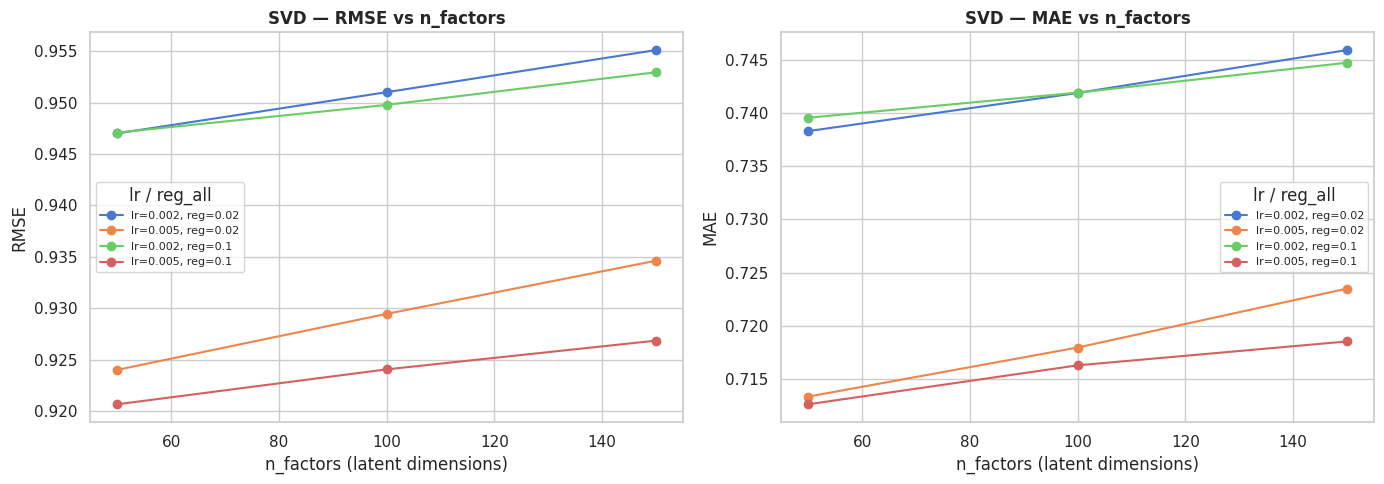

Figure saved → ./results/svd_cv_results.png


In [8]:
# ── Visualise CV results ──────────────────────────────────────────────────────
cv_results = pd.DataFrame(gs.cv_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (metric, label) in enumerate([('mean_test_rmse', 'RMSE'), ('mean_test_mae', 'MAE')]):
    for reg in [0.02, 0.1]:
        for lr in [0.002, 0.005]:
            sub   = cv_results[
                (cv_results['param_reg_all'] == reg) &
                (cv_results['param_lr_all']  == lr)
            ]
            pivot = sub.groupby('param_n_factors')[metric].mean()
            axes[i].plot(
                pivot.index, pivot.values,
                marker='o', label=f'lr={lr}, reg={reg}'
            )
    axes[i].set_title(f'SVD — {label} vs n_factors', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('n_factors (latent dimensions)')
    axes[i].set_ylabel(label)
    axes[i].legend(title='lr / reg_all', fontsize=8)

plt.tight_layout()
plt.savefig('./results/svd_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → ./results/svd_cv_results.png')

---
## 5. Final Evaluation on the Test Set

In [9]:
best_model = gs.best_estimator['rmse']
best_model.fit(trainset)
predictions = best_model.test(testset)

rmse = accuracy.rmse(predictions, verbose=False)
mae  = accuracy.mae(predictions,  verbose=False)

print('════════════════════════════════════════════════')
print('  SVD (Matrix Factorization) — Test Results')
print('════════════════════════════════════════════════')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print('════════════════════════════════════════════════')
bp = gs.best_params['rmse']
print(f"\n  Best params →  n_factors={bp['n_factors']}  |  n_epochs={bp['n_epochs']}  |  lr_all={bp['lr_all']}  |  reg_all={bp['reg_all']}")

════════════════════════════════════════════════
  SVD (Matrix Factorization) — Test Results
════════════════════════════════════════════════
  RMSE : 0.9109
  MAE  : 0.7076
════════════════════════════════════════════════

  Best params →  n_factors=50  |  n_epochs=30  |  lr_all=0.005  |  reg_all=0.1


---
## 6. Learning Curve — RMSE vs. Number of Epochs

Re-train the best SVD configuration while recording training loss at each epoch to confirm convergence and rule out overfitting.

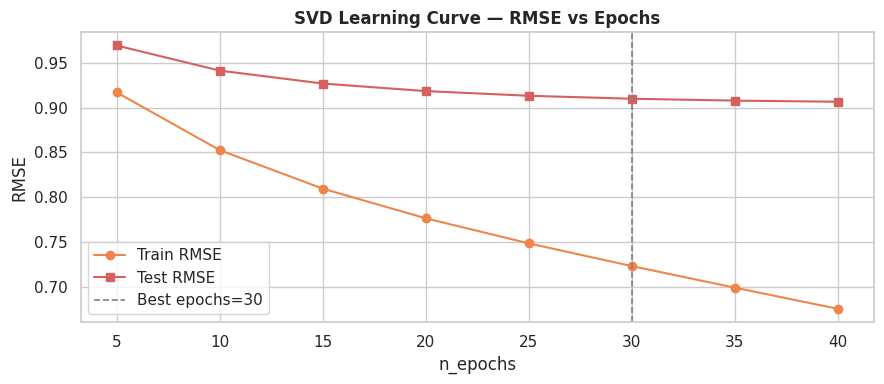

Figure saved → ./results/svd_learning_curve.png


In [10]:
bp = gs.best_params['rmse']

epoch_range  = list(range(5, bp['n_epochs'] + 15, 5))
train_rmses  = []
test_rmses   = []

for ep in epoch_range:
    model = SVD(
        n_factors=bp['n_factors'],
        n_epochs=ep,
        lr_all=bp['lr_all'],
        reg_all=bp['reg_all'],
        random_state=42
    )
    model.fit(trainset)

    train_preds = model.test(trainset.build_testset())
    test_preds  = model.test(testset)

    train_rmses.append(accuracy.rmse(train_preds, verbose=False))
    test_rmses.append(accuracy.rmse(test_preds,   verbose=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epoch_range, train_rmses, marker='o', label='Train RMSE', color=sns.color_palette('muted')[1])
ax.plot(epoch_range, test_rmses,  marker='s', label='Test RMSE',  color=sns.color_palette('muted')[3])
ax.axvline(bp['n_epochs'], color='grey', linestyle='--', linewidth=1.2, label=f"Best epochs={bp['n_epochs']}")
ax.set_title('SVD Learning Curve — RMSE vs Epochs', fontsize=12, fontweight='bold')
ax.set_xlabel('n_epochs')
ax.set_ylabel('RMSE')
ax.legend()

plt.tight_layout()
plt.savefig('./results/svd_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → ./results/svd_learning_curve.png')

---
## 7. Error Analysis — Prediction Residuals

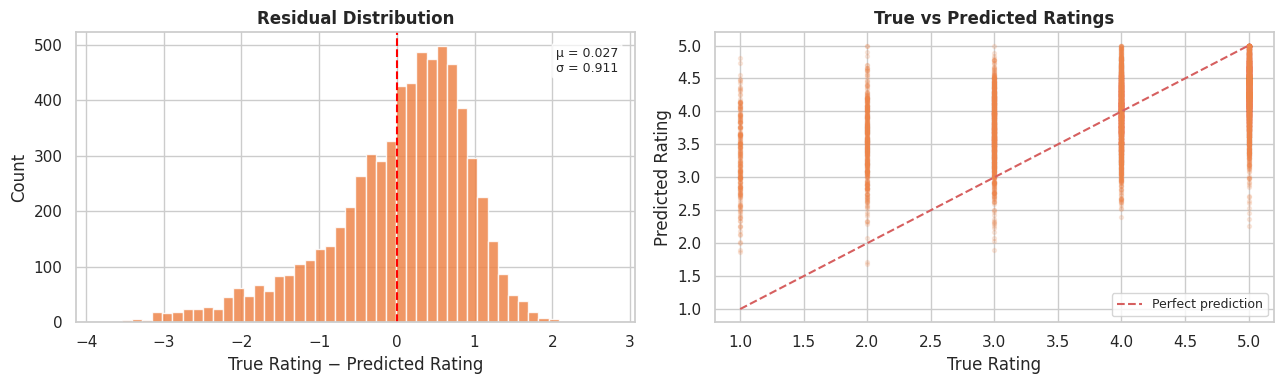

Figure saved → ./results/svd_error_analysis.png


In [11]:
true_r    = np.array([p.r_ui for p in predictions])
est_r     = np.array([p.est  for p in predictions])
residuals = true_r - est_r
palette   = sns.color_palette('muted')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Residual histogram
axes[0].hist(residuals, bins=50, color=palette[1], edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('True Rating − Predicted Rating')
axes[0].set_ylabel('Count')
stats_txt = f'μ = {np.mean(residuals):.3f}\nσ = {np.std(residuals):.3f}'
axes[0].text(0.97, 0.95, stats_txt, transform=axes[0].transAxes,
             ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# True vs Predicted scatter
axes[1].scatter(true_r, est_r, alpha=0.15, s=8, color=palette[1])
axes[1].plot([RATING_MIN, RATING_MAX], [RATING_MIN, RATING_MAX],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[1].set_title('True vs Predicted Ratings', fontsize=12, fontweight='bold')
axes[1].set_xlabel('True Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('./results/svd_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → ./results/svd_error_analysis.png')

---
## 8. Save Results

In [12]:
bp = gs.best_params['rmse']

results_df = pd.DataFrame([{
    'Algorithm':   'SVD (Matrix Factorization)',
    'RMSE':        round(rmse, 4),
    'MAE':         round(mae, 4),
    'n_factors':   bp['n_factors'],
    'n_epochs':    bp['n_epochs'],
    'lr_all':      bp['lr_all'],
    'reg_all':     bp['reg_all'],
    'CV_folds':    5,
    'train_ratio': 0.80,
}])

results_df.to_csv('./results/algorithm_4_svd_results.csv', index=False)
print('Results saved → ./results/algorithm_4_svd_results.csv')
results_df

Results saved → ./results/algorithm_4_svd_results.csv


,Algorithm,RMSE,MAE,n_factors,n_epochs,lr_all,reg_all,CV_folds,train_ratio
0,SVD (Matrix Factorization),0.9109,0.7076,50,30,0.005,0.1,5,0.8


---
## 9. Summary

### How SVD (Matrix Factorization) Works
SVD decomposes the sparse user-item rating matrix **R** into two low-rank matrices:

$$\hat{r}_{ui} = \mu + b_u + b_i + q_i^T p_u$$

where:
- $\mu$ is the global mean rating
- $b_u$, $b_i$ are user and item bias terms
- $p_u \in \mathbb{R}^f$ is the latent **user** factor vector
- $q_i \in \mathbb{R}^f$ is the latent **item** factor vector
- $f$ = `n_factors` (tuned hyperparameter)

Parameters are learned by minimising regularised squared error via **SGD**.

### Why SVD Excels on Sparse Data
- Latent factors **compress** the rating matrix, capturing global patterns that nearest-neighbour methods miss.
- The bias terms explicitly model systematic over/under-rating by specific users or items.
- Regularisation (`reg_all`) prevents overfitting to the small fraction of observed ratings.

### Preprocessing Decisions
| Step | Rationale |
|------|-----------|
| Drop NaNs & out-of-range ratings | Remove corrupted entries |
| Deduplicate `(user, item)` pairs | Prevent data leakage across splits |
| Cold-start filter (≥ 5 ratings) | Ensures stable bias estimates during SGD |
| 80/20 split (`random_state=42`) | Reproducible; consistent across all project notebooks |